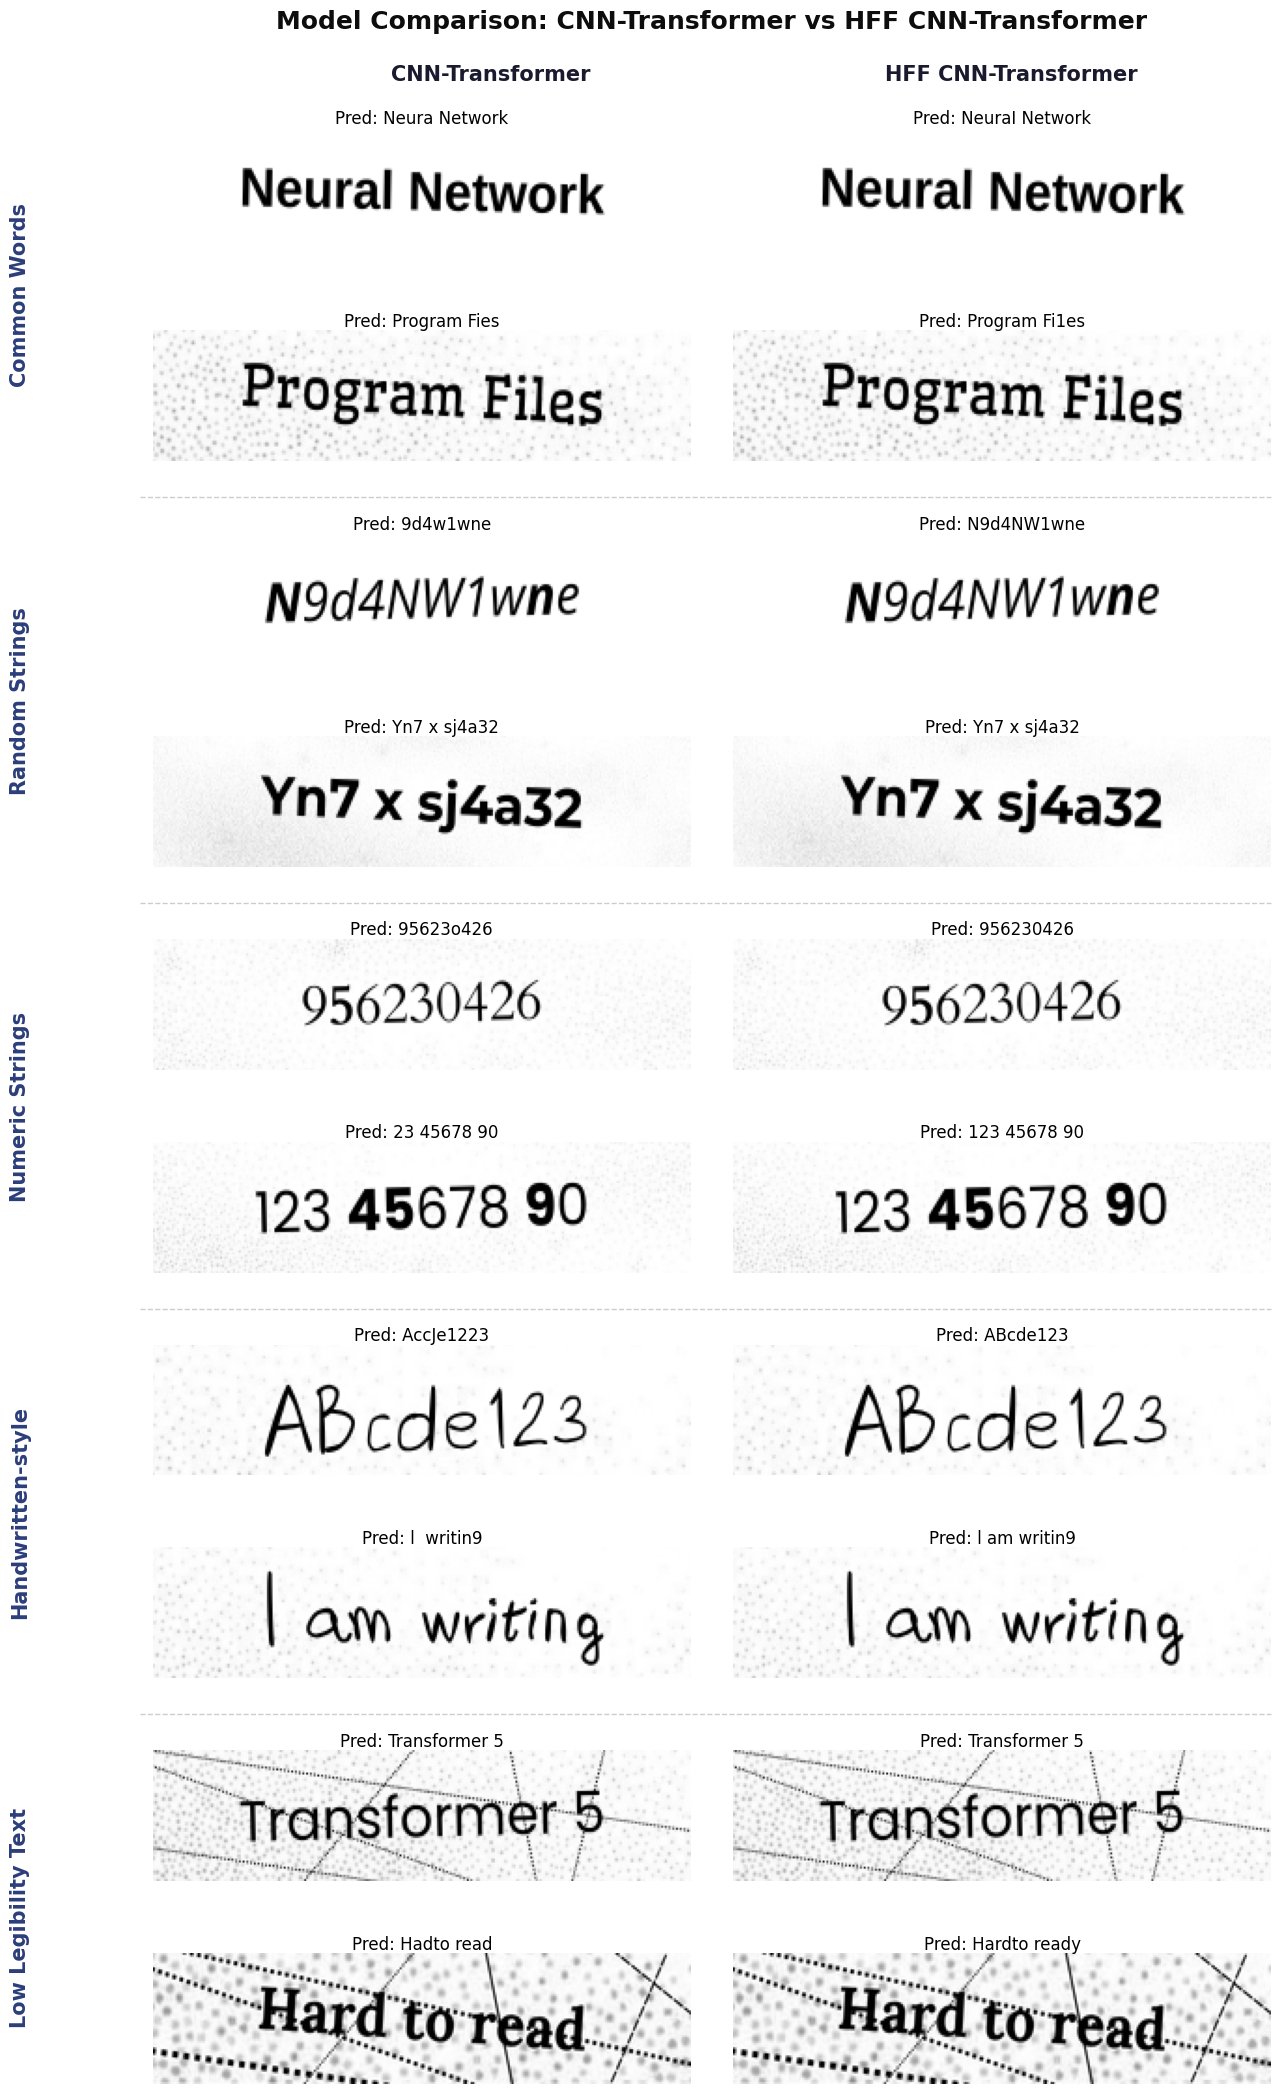

In [52]:
from models.model_hff_cnn_transformer import HFFCNNTransformerOCR
from models.model_cnn_transformer import CNNTransformerOCR, idx2char
from config import *
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PATH     = "saved_models/cnn_transformer_ctc_best.pt"
PATH_HFF = "saved_models/cnn_hff_cnn_transformer_ctc_best.pt"

@torch.no_grad()
def greedy_decode(logits):
    preds = logits.argmax(dim=2).squeeze(1).tolist()
    out, prev = [], None
    for p in preds:
        if p != prev and p != 0:
            out.append(idx2char[p])
        prev = p
    return "".join(out)

num_classes = 1 + len(ALPHABET)

model = CNNTransformerOCR(num_classes)
model.load_state_dict(torch.load(PATH, map_location=DEVICE)["model"])
model.to(DEVICE).eval()

model_hff = HFFCNNTransformerOCR(num_classes)
model_hff.load_state_dict(torch.load(PATH_HFF, map_location=DEVICE)["model"])
model_hff.to(DEVICE).eval()

tf = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

groups = [
    ("Common Words",       list(range(1, 3))),
    ("Random Strings",     list(range(3, 5))),
    ("Numeric Strings",    list(range(5, 7))),
    ("Handwritten-style",  list(range(7, 9))),
    ("Low Legibility Text",list(range(9, 11))),
]

all_indices = [i for _, idxs in groups for i in idxs]
images, preds, preds_hff = {}, {}, {}

for idx in all_indices:
    img = Image.open(f"dataset/testing_images/{idx}.png").convert("L")
    x = tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        preds[idx] = greedy_decode(model(x))
        preds_hff[idx] = greedy_decode(model_hff(x))
    images[idx] = img

total_rows = sum(len(idxs) for _, idxs in groups)

fig = plt.figure(figsize=(13, total_rows * 2.0 + 1.5))
fig.subplots_adjust(top=0.93, bottom=0.02, left=0.12, right=0.98, hspace=0.55, wspace=0.08)

axes = []
for r in range(total_rows):
    ax_l = fig.add_subplot(total_rows, 2, r * 2 + 1)
    ax_r = fig.add_subplot(total_rows, 2, r * 2 + 2)
    axes.append((ax_l, ax_r))

fig.text(0.38, 0.955, "CNN-Transformer", ha="center", va="center", fontsize=15, fontweight="bold", color="#1a1a2e")
fig.text(0.78, 0.955, "HFF CNN-Transformer", ha="center", va="center", fontsize=15, fontweight="bold", color="#1a1a2e")

fig.text(0.55, 0.985, "Model Comparison: CNN-Transformer vs HFF CNN-Transformer", ha="center", va="top", fontsize=18, fontweight="bold", color="#0d0d0d")

row = 0
group_row_ranges = []

for section_title, idxs in groups:
    group_start = row
    for img_idx in idxs:
        ax_l, ax_r = axes[row]
        ax_l.imshow(images[img_idx], cmap="gray", aspect="auto")
        ax_l.set_title(f"Pred: {preds[img_idx]}", fontsize=12, pad=3)
        ax_l.axis("off")
        ax_r.imshow(images[img_idx], cmap="gray", aspect="auto")
        ax_r.set_title(f"Pred: {preds_hff[img_idx]}", fontsize=12, pad=3)
        ax_r.axis("off")
        row += 1

    group_row_ranges.append((section_title, group_start, row - 1))

fig.canvas.draw()

for section_title, r_start, r_end in group_row_ranges:
    pos_top = axes[r_start][0].get_position()
    pos_bot = axes[r_end][0].get_position()
    cy = (pos_top.y1 + pos_bot.y0) / 2

    fig.text(0.01, cy, section_title, ha="left", va="center", fontsize=15, fontweight="bold", color="#2c3e7a", rotation=90)

    if r_start > 0:
        pos_prev_bot = axes[r_start - 1][0].get_position()
        line_y = (pos_top.y1 + pos_prev_bot.y0) / 2
        line = Line2D([0.11, 0.98], [line_y, line_y], transform=fig.transFigure, color="#cccccc", linewidth=1.0, linestyle="--")
        fig.add_artist(line)

plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
plt.show()